In [8]:
import sys

import Vares

if Vares in sys.modules:
    del sys.modules[Vares]


import pandas as pd
import jax.numpy as jnp
import numpy as np 
import matplotlib.pyplot as plt

In [9]:
df = pd.read_excel('hist.xlsx')
print(df.head())
usd_price = df['USD'].to_numpy()
eur_price = df['EUR'].to_numpy()
cny_price = df['CNY'].to_numpy()

        date      USD      EUR      CNY
0 2019-01-10  67.0795  76.9066  98.1498
1 2019-01-11  66.8605  77.2105  98.6216
2 2019-01-12  66.9167  77.1282  99.1491
3 2019-01-15  67.1920  77.0692  99.4318
4 2019-01-16  67.0820  76.9498  99.3292


In [10]:
#yuan handling 
mask = cny_price > 60 
cny_price[mask] = cny_price[mask]/10 #ensuring cohesion
cny_price

array([ 9.81498,  9.86216,  9.91491, ..., 11.4165 , 11.5581 , 11.3685 ],
      shape=(1667,))

In [11]:
def return_array(prices): 
    rets = np.diff(prices) / prices[:-1]
    rets = jnp.array(rets, dtype='float64')
    return rets 

cny_rets = return_array(cny_price)
usd_rets = return_array(usd_price)
eur_rets = return_array(eur_price)

print(np.mean(cny_rets), np.mean(usd_rets), np.mean(eur_rets))
zst = np.mean(cny_rets) / ((np.var(cny_rets)/len(cny_rets))**(1/2))
print(zst)

0.00016318936116112862 0.0001965379047732494 0.00021139672998228307
0.5400929741898858


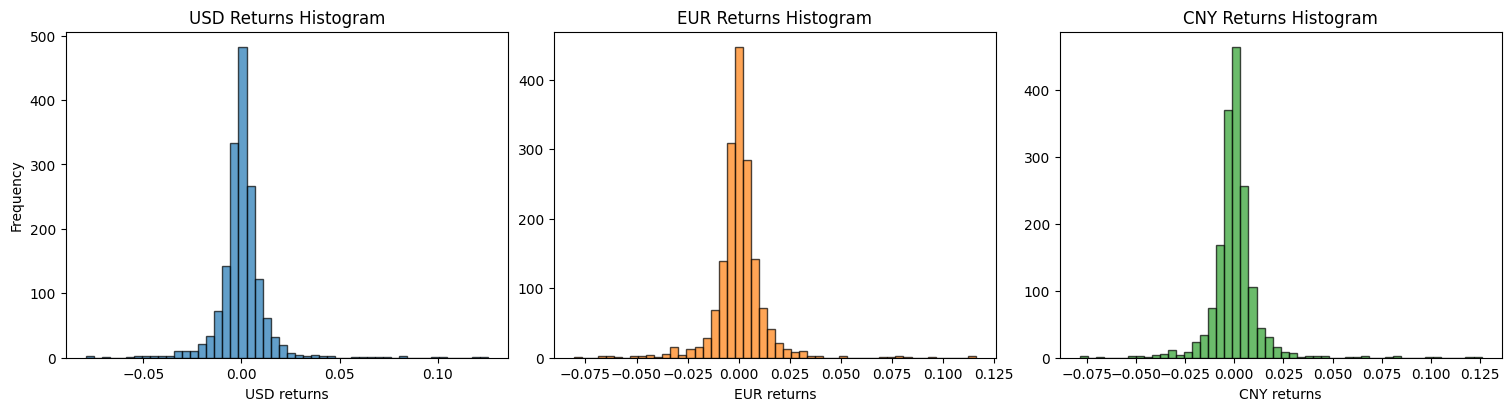

In [12]:
# plot histograms for the three price arrays already present in the notebook
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(usd_rets, bins=50, color='tab:blue', edgecolor='k', alpha=0.7)
axes[0].set_title('USD Returns Histogram')
axes[0].set_xlabel('USD returns')
axes[0].set_ylabel('Frequency')

axes[1].hist(eur_rets, bins=50, color='tab:orange', edgecolor='k', alpha=0.7)
axes[1].set_title('EUR Returns Histogram')
axes[1].set_xlabel('EUR returns')

axes[2].hist(cny_rets, bins=50, color='tab:green', edgecolor='k', alpha=0.7)
axes[2].set_title('CNY Returns Histogram')
axes[2].set_xlabel('CNY returns')

plt.show()

In [29]:
for _ in [usd_rets, cny_rets, eur_rets]: 
    Vares.Test.var_all_methods(_, 0.01)
    print('=========================================')

Historical VaR: 0.03268264690152301
Parametric VaR: 0.028770317451891556
GARCH(1,1) with Normal distribution VaR: 0.02519275402969398
GARCH(1,1) with Student distribution VaR: 0.03311191147299352
IMPORTANT 83 1666 0.03669500070791336 -0.022614352415433688 5
!!!!!!!!!!FLAG
EVT VaR 0.07299237084563931
Historical VaR: 0.03430672012839299
Parametric VaR: 0.02852713585555889
GARCH(1,1) with Normal distribution VaR: 0.025657026267490113
GARCH(1,1) with Student distribution VaR: 0.03411462528257083
IMPORTANT 83 1666 0.036733293090887076 -0.030860394570881054 5
!!!!!!!!!!FLAG
EVT VaR 0.07202508761722377
Historical VaR: 0.03661629868244053
Parametric VaR: 0.02943693137268712
GARCH(1,1) with Normal distribution VaR: 0.020847540213492832
GARCH(1,1) with Student distribution VaR: 0.027051897078091195
IMPORTANT 83 1666 0.036811256024223124 -0.04617306175461445 5
!!!!!!!!!!FLAG
EVT VaR 0.07197256070592445


In [35]:
#test for difference of distributions (copy of the test below)

usd_rets_np = np.asarray(usd_rets)
eur_rets_np = np.asarray(eur_rets)
cny_rets_np = np.asarray(cny_rets)


alpha = 0.05  # significance level

def run_ks(x, y, name):
    stat, pvalue = ks_2samp(x, y)
    print(f"{name} KS statistic = {stat:.4f}, p-value = {pvalue:.4f}")
    if pvalue < alpha:
        print(f"Conclusion for {name}: p < {alpha} -> reject H0. Distributions differ.\n")
    else:
        print(f"Conclusion for {name}: p >= {alpha} -> fail to reject H0. No evidence distributions differ.\n")

run_ks(usd_rets_np, cny_rets_np, "USD vs CNY")
run_ks(cny_rets_np, eur_rets_np, "CNY vs EUR")
run_ks(eur_rets_np, usd_rets_np, "EUR vs USD")

USD vs CNY KS statistic = 0.0192, p-value = 0.9185
Conclusion for USD vs CNY: p >= 0.05 -> fail to reject H0. No evidence distributions differ.

CNY vs EUR KS statistic = 0.0264, p-value = 0.6067
Conclusion for CNY vs EUR: p >= 0.05 -> fail to reject H0. No evidence distributions differ.

EUR vs USD KS statistic = 0.0210, p-value = 0.8559
Conclusion for EUR vs USD: p >= 0.05 -> fail to reject H0. No evidence distributions differ.



DATA SPLIT: COVID PERIOD AND Z PERIOD

In [13]:
covid_df = df[:750]

svo_df = df[750:]
svo_df_strong_ruble = svo_df[500:]

In [14]:
usd_covid = usd_rets[:750]
usd_svo = usd_rets[750:]
usd_late_svo = usd_rets[1250:]

cny_covid = cny_rets[:750]
cny_svo = cny_rets[750:]
cny_late_svo =cny_rets[1250:]


eur_covid = eur_rets[:750]
eur_svo = eur_rets[750:]
eur_late_svo = eur_rets[1250:]


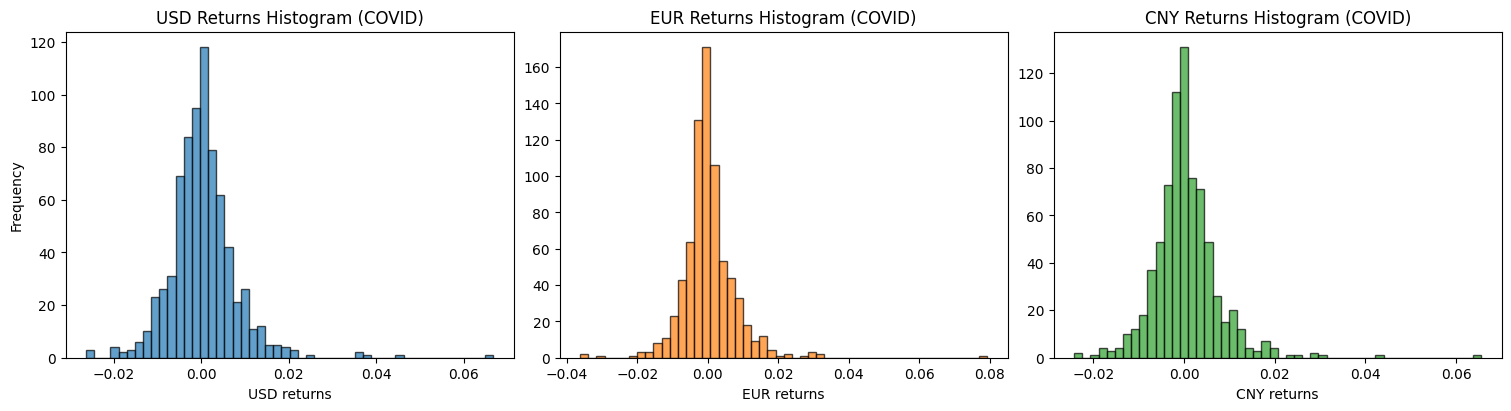

In [15]:
# plot histograms for the three price arrays already present in the notebook
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(usd_covid, bins=50, color='tab:blue', edgecolor='k', alpha=0.7)
axes[0].set_title('USD Returns Histogram (COVID)')
axes[0].set_xlabel('USD returns')
axes[0].set_ylabel('Frequency')

axes[1].hist(eur_covid, bins=50, color='tab:orange', edgecolor='k', alpha=0.7)
axes[1].set_title('EUR Returns Histogram (COVID)')
axes[1].set_xlabel('EUR returns')

axes[2].hist(cny_covid, bins=50, color='tab:green', edgecolor='k', alpha=0.7)
axes[2].set_title('CNY Returns Histogram (COVID)')
axes[2].set_xlabel('CNY returns')

plt.show()

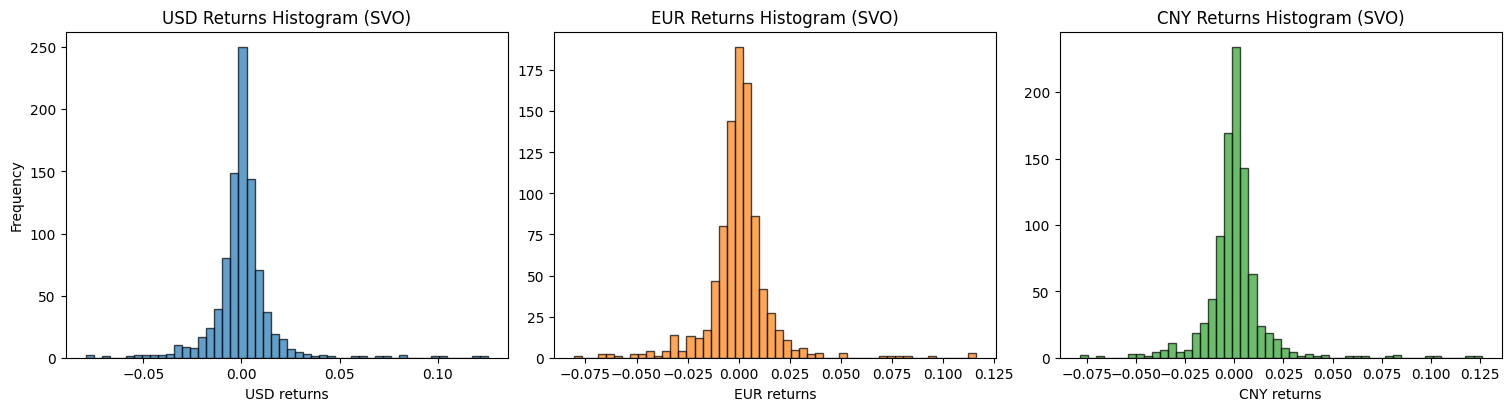

In [16]:
# plot histograms for the three price arrays already present in the notebook
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(usd_svo, bins=50, color='tab:blue', edgecolor='k', alpha=0.7)
axes[0].set_title('USD Returns Histogram (SVO)')
axes[0].set_xlabel('USD returns')
axes[0].set_ylabel('Frequency')

axes[1].hist(eur_svo, bins=50, color='tab:orange', edgecolor='k', alpha=0.7)
axes[1].set_title('EUR Returns Histogram (SVO)')
axes[1].set_xlabel('EUR returns')

axes[2].hist(cny_svo, bins=50, color='tab:green', edgecolor='k', alpha=0.7)
axes[2].set_title('CNY Returns Histogram (SVO)')
axes[2].set_xlabel('CNY returns')

plt.show()

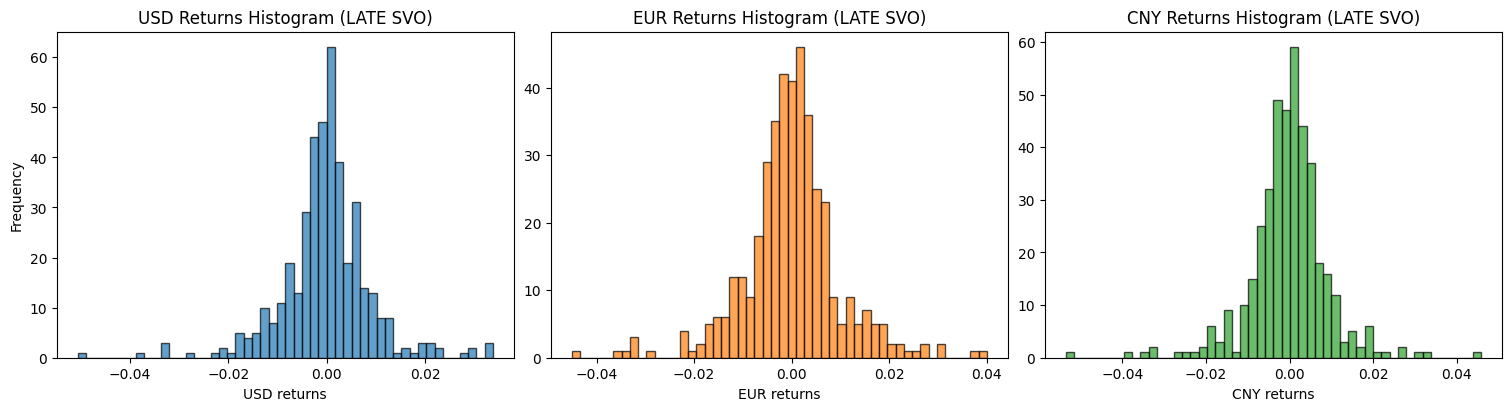

In [17]:
# plot histograms for the three price arrays already present in the notebook
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(usd_late_svo, bins=50, color='tab:blue', edgecolor='k', alpha=0.7)
axes[0].set_title('USD Returns Histogram (LATE SVO)')
axes[0].set_xlabel('USD returns')
axes[0].set_ylabel('Frequency')

axes[1].hist(eur_late_svo, bins=50, color='tab:orange', edgecolor='k', alpha=0.7)
axes[1].set_title('EUR Returns Histogram (LATE SVO)')
axes[1].set_xlabel('EUR returns')

axes[2].hist(cny_late_svo, bins=50, color='tab:green', edgecolor='k', alpha=0.7)
axes[2].set_title('CNY Returns Histogram (LATE SVO)')
axes[2].set_xlabel('CNY returns')

plt.show()

In [ ]:
#prompt: Do simple kolmogorov smirnov test for (usd_covid, usd_svo), (cny_covid, cny_svo) and (eur_covid, eur_svo). Make explicit conclusions. Write simplistic code
from scipy.stats import ks_2samp

# convert JAX arrays to numpy (np is already imported in the notebook)
usd_covid_np = np.asarray(usd_covid)
usd_svo_np = np.asarray(usd_svo)

cny_covid_np = np.asarray(cny_covid)
cny_svo_np = np.asarray(cny_svo)

eur_covid_np = np.asarray(eur_covid)
eur_svo_np = np.asarray(eur_svo)

alpha = 0.05  # significance level

run_ks(usd_covid_np, usd_svo_np, "USD (COVID vs SVO)")
run_ks(cny_covid_np, cny_svo_np, "CNY (COVID vs SVO)")
run_ks(eur_covid_np, eur_svo_np, "EUR (COVID vs SVO)")

USD (COVID vs SVO) KS statistic = 0.0808, p-value = 0.0085
Conclusion for USD (COVID vs SVO): p < 0.05 -> reject H0. Distributions differ.

CNY (COVID vs SVO) KS statistic = 0.0946, p-value = 0.0011
Conclusion for CNY (COVID vs SVO): p < 0.05 -> reject H0. Distributions differ.

EUR (COVID vs SVO) KS statistic = 0.1139, p-value = 0.0000
Conclusion for EUR (COVID vs SVO): p < 0.05 -> reject H0. Distributions differ.



In [28]:
Vares.ENABLE_TIMING = False
for _ in [usd_covid, cny_covid, eur_covid, usd_svo, cny_svo, eur_svo]: 
    Vares.Test.var_all_methods(_, 0.01)
    print('=========================================')

Historical VaR: 0.017998974171870945
Parametric VaR: 0.017513623175730728
GARCH(1,1) with Normal distribution VaR: 0.018326310652647684
GARCH(1,1) with Student distribution VaR: 0.0237553843150514
IMPORTANT 37 750 0.01328798441812106 0.017387657224075755 5
EVT VaR 0.032246534554493
Historical VaR: 0.01677555921134252
Parametric VaR: 0.016203573014565407
GARCH(1,1) with Normal distribution VaR: 0.019072565349664082
GARCH(1,1) with Student distribution VaR: 0.025652479697768994
IMPORTANT 37 750 0.013286677463220601 0.019826789979250446 5
EVT VaR 0.031300618372681555
Historical VaR: 0.01730251340257436
Parametric VaR: 0.017433572456079943
GARCH(1,1) with Normal distribution VaR: 0.01816199029198519
GARCH(1,1) with Student distribution VaR: 0.02316895592175092
IMPORTANT 37 750 0.013296868978991381 0.002417215542575286 5
EVT VaR 0.031491665729238026
Historical VaR: 0.043622698581250605
Parametric VaR: 0.03545064046057579
GARCH(1,1) with Normal distribution VaR: 0.02691613629318366
GARCH(1,1

In [ ]:
#COPILOT PROMPT: Provide concise test for _covid arrays for normality. 
from scipy.stats import shapiro, normaltest

alpha = 0.05

def test_normality(name, arr):
    a = np.asarray(arr)
    a = a[~np.isnan(a)]
    s_stat, s_p = shapiro(a)
    n_stat, n_p = normaltest(a)
    print(f"{name}: Shapiro p={s_p:.4f} -> {'normal' if s_p>=alpha else 'not normal'}; "
          f"D'Agostino p={n_p:.4f} -> {'normal' if n_p>=alpha else 'not normal'}")

test_normality("USD_COVID", usd_covid)
test_normality("CNY_COVID", cny_covid)
test_normality("EUR_COVID", eur_covid)

USD_COVID: Shapiro p=0.0000 -> not normal; D'Agostino p=0.0000 -> not normal
CNY_COVID: Shapiro p=0.0000 -> not normal; D'Agostino p=0.0000 -> not normal
EUR_COVID: Shapiro p=0.0000 -> not normal; D'Agostino p=0.0000 -> not normal
